In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans

# set style for plots
sns.set_style('whitegrid')

1. Load the Dataset

In [3]:
# load the dataset
data = pd.read_csv('Mall_Customers.csv')
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


2. Preprocessing

In [4]:
X = data.iloc[:,[3,4]].values

3. Finding the Optimal Number of Cluster (Elbow Method)

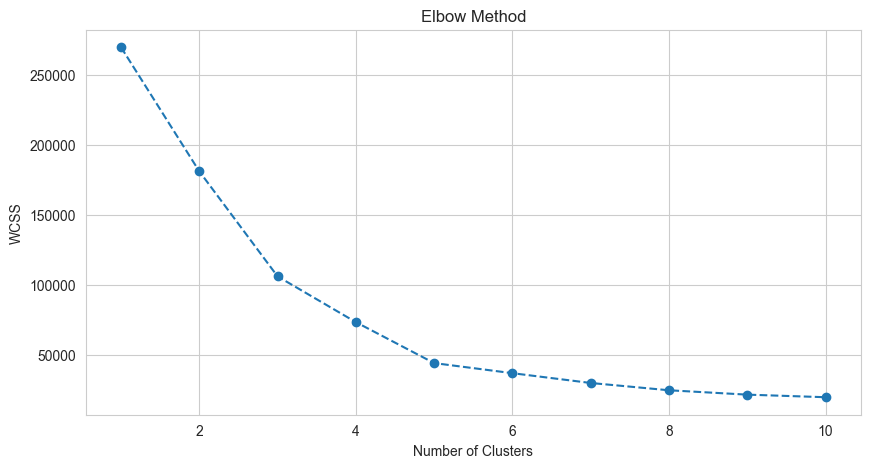

In [5]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i,init='k-means++',random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10,5))
plt.plot(range(1,11),wcss,marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

4. 

In [6]:
kmeans = KMeans(n_clusters=5,init='k-means++',random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)

5.

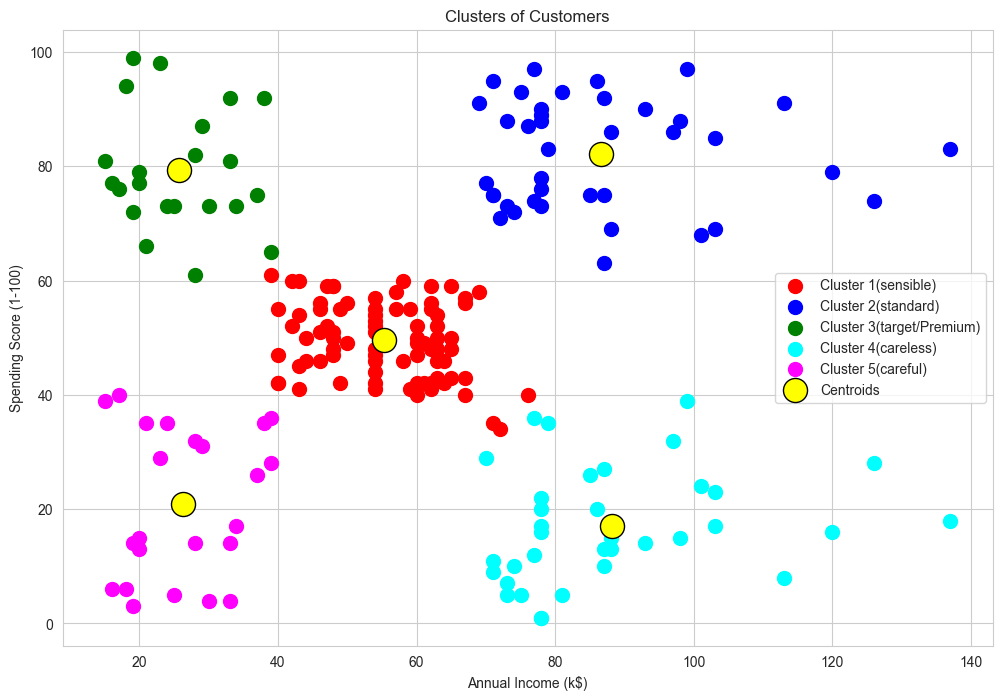

In [7]:
plt.figure(figsize=(12,8))
plt.scatter(X[y_kmeans==0,0], X[y_kmeans==0,1], s=100, c='red', label='Cluster 1(sensible)')
plt.scatter(X[y_kmeans==1,0], X[y_kmeans==1,1], s=100, c='blue', label='Cluster 2(standard)')
plt.scatter(X[y_kmeans==2,0], X[y_kmeans==2,1], s=100, c='green', label='Cluster 3(target/Premium)')
plt.scatter(X[y_kmeans==3,0], X[y_kmeans==3,1], s=100, c='cyan', label='Cluster 4(careless)')
plt.scatter(X[y_kmeans==4,0], X[y_kmeans==4,1], s=100, c='magenta', label='Cluster 5(careful)')

plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=300, c='yellow', label='Centroids', edgecolors='black')
plt.title('Clusters of Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()


In [8]:
def classify_customer():
    try:
        print("=== Market Segmentation Tool ===")
        income = int(input("Enter Annual Income in k$ (e.g., 80): "))
        spending = int(input("Enter Spending Score 1-100 (e.g., 20): "))

        # Predict cluster
        cluster = kmeans.predict([[income, spending]])[0]

        # Descriptive names for clusters based on visualization
        cluster_names = {
            0: "Sensible (High Income, Low Spending)",
            1: "Standard (Average Income, Average Spending)",
            2: "Target/Premium (High Income, High Spending)",
            3: "Careless (Low Income, High Spending)",
            4: "Careful (Low Income, Low Spending)"
        }

        print("\n" + "-"*40)
        print(f"Result: This customer belongs to Group {cluster + 1}")
        print(f"Segment: {cluster_names[cluster]}")
        print("-"*40)

    except ValueError:
        print("Invalid input! Please enter numbers for Income and Spending Score.")

# Call the function
classify_customer()

=== Market Segmentation Tool ===

----------------------------------------
Result: This customer belongs to Group 4
Segment: Careless (Low Income, High Spending)
----------------------------------------
